# Import Libraries

In [1]:
import os
import math
import random
import shutil
import itertools
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import pwlf
from multiprocessing import Pool, cpu_count
from tqdm import tqdm, trange

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import brevitas.nn as qnn
from brevitas.nn import QuantLinear, QuantReLU, QuantConv2d
from brevitas.quant.binary import SignedBinaryActPerTensorConst
from brevitas.quant.binary import SignedBinaryWeightPerTensorConst
from brevitas.inject.enum import QuantType
from brevitas.quant_tensor.int_quant_tensor import IntQuantTensor
from brevitas.function.ops_ste import round_ste

# Network Definition

#### Neuron number and precision in each layer listed in this area for the MLP used in MNIST classification

In [2]:
# -------- Block 0 --------
kernel_num_CONV_layer_0_0 = 64
kernel_num_CONV_layer_0_1 = 64

# -------- Block 1 --------
kernel_num_CONV_layer_1_0 = 128
kernel_num_CONV_layer_1_1 = 128

# -------- Block 2 --------
kernel_num_CONV_layer_2_0 = 256
kernel_num_CONV_layer_2_1 = 256
kernel_num_CONV_layer_2_2 = 256

# -------- Block 3 --------
kernel_num_CONV_layer_3_0 = 512
kernel_num_CONV_layer_3_1 = 512
kernel_num_CONV_layer_3_2 = 512

# -------- Block 4 --------
kernel_num_CONV_layer_4_0 = 512
kernel_num_CONV_layer_4_1 = 512
kernel_num_CONV_layer_4_2 = 512

neuron_num_FC_layer_0 = 1024
neuron_num_FC_layer_1 = 1024
neuron_num_OUT_layer  = 100

precision_CONV_layer_0_0 = 1
precision_CONV_layer_0_1 = 1

precision_CONV_layer_1_0 = 1
precision_CONV_layer_1_1 = 1

precision_CONV_layer_2_0 = 1
precision_CONV_layer_2_1 = 1
precision_CONV_layer_2_2 = 1

precision_CONV_layer_3_0 = 1
precision_CONV_layer_3_1 = 1
precision_CONV_layer_3_2 = 1

precision_CONV_layer_4_0 = 1
precision_CONV_layer_4_1 = 1
precision_CONV_layer_4_2 = 1

precision_FC_layer_0  = 1
precision_FC_layer_1  = 1
precision_OUT_layer   = 1

#### Hyperparameters setting here.

In [3]:
epochs = 200
batch_sizes = [128, 256, 512]
dropout_rates = [0.0, 0.05, 0.1]
lr_max_pool = [0.01, 0.001, 0.0005, 0.0002]
lr_min_pool = [0.00001]

#### GPU selection. After decided which GPU to train, don't change it before completing the training

In [4]:
GPU_device = "cuda:0"

#### Training date output folder path, for different network model setting, please change the name of save_path

In [5]:
save_path     = "VGG16_1bit"

project_root  = os.path.abspath(".")
dataset_root  = os.path.join(project_root, "dataset")
train_root    = os.path.join(project_root, "train")
output_root   = os.path.join(train_root, save_path)
report_root  = os.path.join(project_root, "report")

print("Dataset Download Path: ", dataset_root, "\n")
print("Training Data Output Path: ", output_root, "\n")
print("Training Report Output Path: ", report_root)

os.makedirs(dataset_root, exist_ok=True)
os.makedirs(output_root, exist_ok=True)
os.makedirs(report_root, exist_ok=True)

Dataset Download Path:  /home/yuhao/project/new_tutorial/QModels-Brevitas-Example/example/basic_model/classification/CIFAR100/dataset 

Training Data Output Path:  /home/yuhao/project/new_tutorial/QModels-Brevitas-Example/example/basic_model/classification/CIFAR100/train/VGG16_1bit 

Training Report Output Path:  /home/yuhao/project/new_tutorial/QModels-Brevitas-Example/example/basic_model/classification/CIFAR100/report


#### Following are the code to complete the network definition

In [6]:
def int_range(act_bit_width):
    if (act_bit_width>1):
        min_val = -2.0**(act_bit_width-1.0)
        max_val = 2.0**(act_bit_width-1.0)-1.0
    else:
        min_val = -1.0
        max_val = 1.0
    return min_val, max_val

In [7]:
kernel_size      = (3,3) 

In [8]:
in_channel_0_0   = 3
out_channel_0_0  = kernel_num_CONV_layer_0_0 
in_channel_0_1   = kernel_num_CONV_layer_0_0
out_channel_0_1  = kernel_num_CONV_layer_0_1 

in_channel_1_0   = kernel_num_CONV_layer_0_1
out_channel_1_0  = kernel_num_CONV_layer_1_0
in_channel_1_1   = kernel_num_CONV_layer_1_0
out_channel_1_1  = kernel_num_CONV_layer_1_1 

in_channel_2_0   = kernel_num_CONV_layer_1_1
out_channel_2_0  = kernel_num_CONV_layer_2_0
in_channel_2_1   = kernel_num_CONV_layer_2_0
out_channel_2_1  = kernel_num_CONV_layer_2_1 
in_channel_2_2   = kernel_num_CONV_layer_2_1
out_channel_2_2  = kernel_num_CONV_layer_2_2

in_channel_3_0   = kernel_num_CONV_layer_2_2
out_channel_3_0  = kernel_num_CONV_layer_3_0
in_channel_3_1   = kernel_num_CONV_layer_3_0
out_channel_3_1  = kernel_num_CONV_layer_3_1
in_channel_3_2   = kernel_num_CONV_layer_3_1
out_channel_3_2  = kernel_num_CONV_layer_3_2

in_channel_4_0   = kernel_num_CONV_layer_3_2
out_channel_4_0  = kernel_num_CONV_layer_4_0
in_channel_4_1   = kernel_num_CONV_layer_4_0
out_channel_4_1  = kernel_num_CONV_layer_4_1
in_channel_4_2   = kernel_num_CONV_layer_4_1
out_channel_4_2  = kernel_num_CONV_layer_4_2

# VGG16 on CIFAR10: 32 -> 16 -> 8 -> 4 -> 2 after 4 pools
input_length     = 2*2*kernel_num_CONV_layer_4_2

hidden_0         = neuron_num_FC_layer_0  
hidden_1         = neuron_num_FC_layer_1

output_length    = neuron_num_OUT_layer 

In [9]:
conv_0_0_bit_width = precision_CONV_layer_0_0
conv_0_1_bit_width = precision_CONV_layer_0_1

conv_1_0_bit_width = precision_CONV_layer_1_0
conv_1_1_bit_width = precision_CONV_layer_1_1

conv_2_0_bit_width = precision_CONV_layer_2_0
conv_2_1_bit_width = precision_CONV_layer_2_1
conv_2_2_bit_width = precision_CONV_layer_2_2

conv_3_0_bit_width = precision_CONV_layer_3_0
conv_3_1_bit_width = precision_CONV_layer_3_1
conv_3_2_bit_width = precision_CONV_layer_3_2

conv_4_0_bit_width = precision_CONV_layer_4_0
conv_4_1_bit_width = precision_CONV_layer_4_1
conv_4_2_bit_width = precision_CONV_layer_4_2

fc_0_bit_width = precision_FC_layer_0
fc_1_bit_width = precision_FC_layer_1
out_bit_width  = precision_OUT_layer

In [10]:
min_val, max_val = int_range(conv_0_0_bit_width)

In [11]:
class VGG16(nn.Module):
    def __init__(self, dropout=0.5):
        super(VGG16, self).__init__()
        
        self.input_bin  = qnn.QuantIdentity(
                         quant_type='binary',
                         scaling_impl_type='const',
                         bit_width=conv_0_0_bit_width,
                         min_val=min_val,
                         max_val=max_val, 
                         return_quant_tensor=True)
        self.input_quan = qnn.QuantIdentity(
                         quant_type='int',
                         scaling_impl_type='const',
                         bit_width=conv_0_0_bit_width,
                         min_val=min_val,
                         max_val=max_val, 
                         return_quant_tensor=True)
        
        # ---------------- Block 0 (2 conv) ----------------
        self.conv0_0_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_0_0,
                         out_channels=out_channel_0_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_0_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv0_0_quan = qnn.QuantConv2d(
                         in_channels=in_channel_0_0,
                         out_channels=out_channel_0_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_0_0_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)
        self.bn0_0   = nn.BatchNorm2d(out_channel_0_0)
        self.act0_0  = qnn.QuantReLU(
                         bit_width=conv_0_1_bit_width, 
                         return_quant_tensor=True)
        self.drop0_0 = nn.Dropout2d(dropout)
        
        self.conv0_1_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_0_1,
                         out_channels=out_channel_0_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_0_1_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv0_1_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_0_1,
                         out_channels=out_channel_0_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_0_1_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)
        self.bn0_1   = nn.BatchNorm2d(out_channel_0_1)
        self.act0_1  = qnn.QuantReLU(
                         bit_width=conv_1_0_bit_width, 
                         return_quant_tensor=True)
        self.drop0_1 = nn.Dropout2d(dropout)
        
        self.pool0 = nn.MaxPool2d(2)

        # ---------------- Block 1 (2 conv) ----------------
        self.conv1_0_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_1_0,
                         out_channels=out_channel_1_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_1_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False, 
                         return_quant_tensor=True)
        self.conv1_0_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_1_0,
                         out_channels=out_channel_1_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_1_0_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False, 
                         return_quant_tensor=True)
        self.bn1_0   = nn.BatchNorm2d(out_channel_1_0)
        self.act1_0  = qnn.QuantReLU(
                         bit_width=conv_1_1_bit_width, 
                         return_quant_tensor=True)
        self.drop1_0 = nn.Dropout2d(dropout)
        
        self.conv1_1_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_1_1,
                         out_channels=out_channel_1_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_1_1_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False, 
                         return_quant_tensor=True)
        self.conv1_1_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_1_1,
                         out_channels=out_channel_1_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_1_1_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False, 
                         return_quant_tensor=True)
        self.bn1_1   = nn.BatchNorm2d(out_channel_1_1)
        self.act1_1  = qnn.QuantReLU(
                         bit_width=conv_2_0_bit_width, 
                         return_quant_tensor=True)
        self.drop1_1 = nn.Dropout2d(dropout)
        
        self.pool1 = nn.MaxPool2d(2)

        # ---------------- Block 2 (3 conv) ----------------
        self.conv2_0_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_2_0,
                         out_channels=out_channel_2_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_2_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False, 
                         return_quant_tensor=True)
        self.conv2_0_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_2_0,
                         out_channels=out_channel_2_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_2_0_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False, 
                         return_quant_tensor=True)
        self.bn2_0   = nn.BatchNorm2d(out_channel_2_0)
        self.act2_0  = qnn.QuantReLU(
                         bit_width=conv_2_1_bit_width, 
                         return_quant_tensor=True)
        self.drop2_0 = nn.Dropout2d(dropout)
        
        self.conv2_1_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_2_1,
                         out_channels=out_channel_2_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_2_1_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False, 
                         return_quant_tensor=True)
        self.conv2_1_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_2_1,
                         out_channels=out_channel_2_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_2_1_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False, 
                         return_quant_tensor=True)
        self.bn2_1   = nn.BatchNorm2d(out_channel_2_1)
        self.act2_1  = qnn.QuantReLU(
                         bit_width=conv_2_2_bit_width, 
                         return_quant_tensor=True)
        self.drop2_1 = nn.Dropout2d(dropout)

        self.conv2_2_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_2_2,
                         out_channels=out_channel_2_2,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_2_2_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False, 
                         return_quant_tensor=True)
        self.conv2_2_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_2_2,
                         out_channels=out_channel_2_2,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_2_2_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False, 
                         return_quant_tensor=True)
        self.bn2_2   = nn.BatchNorm2d(out_channel_2_2)
        self.act2_2  = qnn.QuantReLU(
                         bit_width=conv_3_0_bit_width, 
                         return_quant_tensor=True)
        self.drop2_2 = nn.Dropout2d(dropout)
        
        self.pool2 = nn.MaxPool2d(2)

        # ---------------- Block 3 (3 conv) ----------------
        self.conv3_0_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_3_0,
                         out_channels=out_channel_3_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_3_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False, 
                         return_quant_tensor=True)
        self.conv3_0_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_3_0,
                         out_channels=out_channel_3_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_3_0_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False, 
                         return_quant_tensor=True)
        self.bn3_0   = nn.BatchNorm2d(out_channel_3_0)
        self.act3_0  = qnn.QuantReLU(
                         bit_width=conv_3_1_bit_width, 
                         return_quant_tensor=True)
        self.drop3_0 = nn.Dropout2d(dropout)

        self.conv3_1_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_3_1,
                         out_channels=out_channel_3_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_3_1_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False, 
                         return_quant_tensor=True)
        self.conv3_1_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_3_1,
                         out_channels=out_channel_3_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_3_1_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False, 
                         return_quant_tensor=True)
        self.bn3_1   = nn.BatchNorm2d(out_channel_3_1)
        self.act3_1  = qnn.QuantReLU(
                         bit_width=conv_3_2_bit_width, 
                         return_quant_tensor=True)
        self.drop3_1 = nn.Dropout2d(dropout)

        self.conv3_2_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_3_2,
                         out_channels=out_channel_3_2,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_3_2_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False, 
                         return_quant_tensor=True)
        self.conv3_2_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_3_2,
                         out_channels=out_channel_3_2,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_3_2_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False, 
                         return_quant_tensor=True)
        self.bn3_2   = nn.BatchNorm2d(out_channel_3_2)
        self.act3_2  = qnn.QuantReLU(
                         bit_width=conv_4_0_bit_width, 
                         return_quant_tensor=True)
        self.drop3_2 = nn.Dropout2d(dropout)

        self.pool3 = nn.MaxPool2d(2)

        # ---------------- Block 4 (3 conv) ----------------
        self.conv4_0_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_4_0,
                         out_channels=out_channel_4_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_4_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False, 
                         return_quant_tensor=True)
        self.conv4_0_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_4_0,
                         out_channels=out_channel_4_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_4_0_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False, 
                         return_quant_tensor=True)
        self.bn4_0   = nn.BatchNorm2d(out_channel_4_0)
        self.act4_0  = qnn.QuantReLU(
                         bit_width=conv_4_1_bit_width, 
                         return_quant_tensor=True)
        self.drop4_0 = nn.Dropout2d(dropout)

        self.conv4_1_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_4_1,
                         out_channels=out_channel_4_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_4_1_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False, 
                         return_quant_tensor=True)
        self.conv4_1_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_4_1,
                         out_channels=out_channel_4_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_4_1_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False, 
                         return_quant_tensor=True)
        self.bn4_1   = nn.BatchNorm2d(out_channel_4_1)
        self.act4_1  = qnn.QuantReLU(
                         bit_width=conv_4_2_bit_width, 
                         return_quant_tensor=True)
        self.drop4_1 = nn.Dropout2d(dropout)

        self.conv4_2_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_4_2,
                         out_channels=out_channel_4_2,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_4_2_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False, 
                         return_quant_tensor=True)
        self.conv4_2_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_4_2,
                         out_channels=out_channel_4_2,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_4_2_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False, 
                         return_quant_tensor=True)
        self.bn4_2   = nn.BatchNorm2d(out_channel_4_2)
        self.act4_2  = qnn.QuantReLU(
                         bit_width=fc_0_bit_width, 
                         return_quant_tensor=True)
        self.drop4_2 = nn.Dropout2d(dropout)

        #self.pool4 = nn.MaxPool2d(2)

        # ---------------- FC (keep your original style) ----------------
        self.fc3_bin  = qnn.QuantLinear(
                         in_features=input_length,
                         out_features=hidden_0,
                         bias=False,
                         weight_bit_width=fc_0_bit_width,
                         weight_quant_type=QuantType.BINARY)
        self.fc3_quan = qnn.QuantLinear(
                         in_features=input_length,
                         out_features=hidden_0,
                         bias=False,
                         weight_bit_width=fc_0_bit_width,
                         weight_quant_type=QuantType.INT)
        self.bn3   = nn.BatchNorm1d(hidden_0)
        self.act3  = qnn.QuantReLU(
                         bit_width=fc_1_bit_width, 
                         return_quant_tensor=True)
        self.drop3 = nn.Dropout(dropout)

        self.fc4_bin  = qnn.QuantLinear(
                         in_features=hidden_0,
                         out_features=hidden_1,
                         bias=False,
                         weight_bit_width=fc_1_bit_width,
                         weight_quant_type=QuantType.BINARY)
        self.fc4_quan = qnn.QuantLinear(
                         in_features=hidden_0,
                         out_features=hidden_1,
                         bias=False,
                         weight_bit_width=fc_1_bit_width,
                         weight_quant_type=QuantType.INT)
        self.bn4   = nn.BatchNorm1d(hidden_1)
        self.act4  = qnn.QuantReLU(
                         bit_width=out_bit_width, 
                         return_quant_tensor=True)
        self.drop4 = nn.Dropout(dropout)

        self.out_bin  = qnn.QuantLinear(
                         in_features=hidden_1,
                         out_features=output_length,
                         bias=False,
                         weight_bit_width=out_bit_width,
                         weight_quant_type=QuantType.BINARY)
        self.out_quan = qnn.QuantLinear(
                         in_features=hidden_1,
                         out_features=output_length,
                         bias=False,
                         weight_bit_width=out_bit_width,
                         weight_quant_type=QuantType.INT)

    def forward(self, x):

        if conv_0_0_bit_width==1:
            out = self.input_bin(x)
        else:
            out = self.input_quan(x)
        
        if conv_0_0_bit_width==1:
            out = self.drop0_0(self.act0_0(self.bn0_0(self.conv0_0_bin(out))))
        else:
            out = self.drop0_0(self.act0_0(self.bn0_0(self.conv0_0_quan(out))))
            
        if conv_0_1_bit_width==1:
            out = self.drop0_1(self.act0_1(self.bn0_1(self.conv0_1_bin(out))))
        else:
            out = self.drop0_1(self.act0_1(self.bn0_1(self.conv0_1_quan(out))))
        
        out = self.pool0(out)

        if conv_1_0_bit_width==1:
            out = self.drop1_0(self.act1_0(self.bn1_0(self.conv1_0_bin(out))))
        else:
            out = self.drop1_0(self.act1_0(self.bn1_0(self.conv1_0_quan(out))))
            
        if conv_1_1_bit_width==1:
            out = self.drop1_1(self.act1_1(self.bn1_1(self.conv1_1_bin(out))))
        else:
            out = self.drop1_1(self.act1_1(self.bn1_1(self.conv1_1_quan(out))))
        
        out = self.pool1(out)

        if conv_2_0_bit_width==1:
            out = self.drop2_0(self.act2_0(self.bn2_0(self.conv2_0_bin(out))))
        else:
            out = self.drop2_0(self.act2_0(self.bn2_0(self.conv2_0_quan(out))))
            
        if conv_2_1_bit_width==1:
            out = self.drop2_1(self.act2_1(self.bn2_1(self.conv2_1_bin(out))))
        else:
            out = self.drop2_1(self.act2_1(self.bn2_1(self.conv2_1_quan(out))))

        if conv_2_2_bit_width==1:
            out = self.drop2_2(self.act2_2(self.bn2_2(self.conv2_2_bin(out))))
        else:
            out = self.drop2_2(self.act2_2(self.bn2_2(self.conv2_2_quan(out))))
        
        out = self.pool2(out)

        if conv_3_0_bit_width==1:
            out = self.drop3_0(self.act3_0(self.bn3_0(self.conv3_0_bin(out))))
        else:
            out = self.drop3_0(self.act3_0(self.bn3_0(self.conv3_0_quan(out))))
            
        if conv_3_1_bit_width==1:
            out = self.drop3_1(self.act3_1(self.bn3_1(self.conv3_1_bin(out))))
        else:
            out = self.drop3_1(self.act3_1(self.bn3_1(self.conv3_1_quan(out))))

        if conv_3_2_bit_width==1:
            out = self.drop3_2(self.act3_2(self.bn3_2(self.conv3_2_bin(out))))
        else:
            out = self.drop3_2(self.act3_2(self.bn3_2(self.conv3_2_quan(out))))
        
        out = self.pool3(out)

        if conv_4_0_bit_width==1:
            out = self.drop4_0(self.act4_0(self.bn4_0(self.conv4_0_bin(out))))
        else:
            out = self.drop4_0(self.act4_0(self.bn4_0(self.conv4_0_quan(out))))
            
        if conv_4_1_bit_width==1:
            out = self.drop4_1(self.act4_1(self.bn4_1(self.conv4_1_bin(out))))
        else:
            out = self.drop4_1(self.act4_1(self.bn4_1(self.conv4_1_quan(out))))

        if conv_4_2_bit_width==1:
            out = self.drop4_2(self.act4_2(self.bn4_2(self.conv4_2_bin(out))))
        else:
            out = self.drop4_2(self.act4_2(self.bn4_2(self.conv4_2_quan(out))))
        
        #out = self.pool4(out)

        out = out.reshape(out.shape[0], -1)

        if fc_0_bit_width==1:
            out = self.drop3(self.act3(self.bn3(self.fc3_bin(out))))
        else:
            out = self.drop3(self.act3(self.bn3(self.fc3_quan(out))))
        
        if fc_1_bit_width==1:
            out = self.drop4(self.act4(self.bn4(self.fc4_bin(out))))
        else:
            out = self.drop4(self.act4(self.bn4(self.fc4_quan(out))))

        if out_bit_width==1:
            out = self.out_bin(out)
        else:
            out = self.out_quan(out)
        
        return out

# Random Seed Utility

In [12]:
def set_random_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Define Dataloader

In [13]:
test_batch_size = 4096

In [14]:
def get_dataloaders(batch_size):    
    CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
    CIFAR100_STD  = (0.2675, 0.2565, 0.2761)

    train_dataset = datasets.CIFAR10(   dataset_root, 
                                        train=True, 
                                        download=True, 
                                        transform = transforms.Compose([
                                            transforms.RandomCrop(32, padding=4),
                                            transforms.RandomHorizontalFlip(),
                                            transforms.ToTensor(),
                                            transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD)
                                        ])
                                    )
    test_dataset  = datasets.CIFAR10(   dataset_root, 
                                        train=False, 
                                        download=True, 
                                        transform = transforms.Compose([
                                            transforms.ToTensor(),
                                            transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD)
                                        ])
                                    )
    val_size = int(0.2 * len(train_dataset))
    train_size = len(train_dataset) - val_size
    train_set, val_set = random_split(train_dataset, [train_size, val_size])
    return (
        DataLoader(
            train_set,
            batch_size=batch_size,
            shuffle=True,
            num_workers=6,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4,
        ),
        DataLoader(
            val_set,
            batch_size=batch_size,
            shuffle=False,
            num_workers=6,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4,
        ),
        DataLoader(test_dataset, batch_size=test_batch_size),
    )

# Evaluation Pipeline

In [15]:
def evaluate(model, criterion, device, loader, train):
    model.eval()
    loss_total, correct, total = 0, 0, 0
    with torch.no_grad():
        if (train):
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                loss_total += loss.item() * x.size(0)
                _, pred = out.max(1)
                correct += (pred == y).sum().item()
                total += x.size(0)
        else:
            for x, y in tqdm(loader, desc="Evaluation", leave=True):
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                loss_total += loss.item() * x.size(0)
                _, pred = out.max(1)
                correct += (pred == y).sum().item()
                total += x.size(0)
    return loss_total / total, correct / total

# Plot Training Loss and Accuracy

In [16]:
def plot_train(history, save_dir):
    # Plot and show
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.legend()
    plt.title("Accuracy")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "training_plot.png"))
    plt.show()

# Training, Validation, and Testing Pipeline

In [17]:
def train_validate_test(config, save_dir):
    set_random_seed()
    os.makedirs(save_dir, exist_ok=True)
    log_file = os.path.join(save_dir, "training_log.txt")
    resume_path = os.path.join(save_dir, "checkpoint.pth")

    epochs, batch_size, lr_max, lr_min, dropout = config
    train_loader, val_loader, test_loader = get_dataloaders(batch_size)
    device = torch.device(GPU_device if torch.cuda.is_available() else "cpu")
    model = VGG16(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr_max)

    start_epoch = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path)
        model.load_state_dict(ckpt["model_state"])
        model.to(device)
        optimizer.load_state_dict(ckpt["optimizer_state"])
        history = ckpt["history"]
        start_epoch = ckpt["epoch"] + 1
        print(f"🔄 Resuming from epoch {start_epoch}")
    else:
        with open(log_file, "w") as f:
            f.write("Training started\n")

    # Training Loop
    t = trange(start_epoch, epochs, desc="Training", leave=True)
    for epoch in t:
        model.train()
        lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * epoch / epochs))
        for g in optimizer.param_groups:
            g["lr"] = lr

        train_loss, correct, total = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x.size(0)
            _, pred = out.max(1)
            correct += (pred == y).sum().item()
            total += x.size(0)

        val_loss, val_acc = evaluate(model, criterion, device, val_loader, train=True)
        train_loss /= total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        log_line = (f"Epoch {epoch+1}/{epochs} - LR: {lr:.6f} | "
                    f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
                    f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
        #print(log_line)
        with open(log_file, "a") as f:
            f.write(log_line + "\n")

        t.set_description("| LR: %.6f | Train Acc: %.4f | Val Acc: %.4f |" % (lr, train_acc, val_acc))
        t.refresh()

        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history": history
        }, resume_path)

    # Plot and show the training history
    plot_train(history, save_dir)

    # Test the original trained model
    original_test_loss, original_test_acc = evaluate(model, criterion, device, test_loader, train=False)
    final_line = f"Original Model Final Test Loss: {original_test_loss:.4f} Accuracy: {original_test_acc:.4f}"
    print(final_line)
    with open(log_file, "a") as f:
        f.write("Training completed\n")
        f.write(final_line + "\n")

    # Save the trained model
    torch.save(model.state_dict(), os.path.join(save_dir, "final_model.pth"))
    with open(log_file, "a") as f:
        f.write(final_line + "\n")
    print("\n")

    return original_test_acc

# Hyperparameter Searching for Network Training and Testing

In [18]:
def Hyperparameter_searching(epochs, batch_sizes, lr_max_pool, lr_min_pool, dropout_rates):
    
    epochs = epochs
    batch_sizes = batch_sizes
    lr_max_pool = lr_max_pool
    lr_min_pool = lr_min_pool
    
    # # Generate descending LR combinations
    # lr_combos = [combo for combo in itertools.product(lr_pool, repeat=3)
    #              if (combo[0] > combo[1] > combo[2]) or (combo[0] == combo[1] == combo[2])]
    
    # all_runs = [
    #     f"batch{bs}_lr{lr1}_{lr2}_{lr3}"
    #     for bs, (lr1, lr2, lr3) in itertools.product(batch_sizes, lr_combos)
    # ]
    
    all_runs = [
        f"batch{bs}_lr_max_{lr_max}_min_{lr_min}"
        for bs, lr_max, lr_min in itertools.product(batch_sizes, lr_max_pool, lr_min_pool)
    ]
    
    completed_runs = []
    for run in all_runs:
        log_path = os.path.join(output_root, run, "training_log.txt")
        if os.path.exists(log_path):
            with open(log_path, "r") as f:
                if any("Training completed" in line for line in f):
                    completed_runs.append(run)
    
    if len(completed_runs) == len(all_runs):
        print("✅ All combinations completed. Restarting from scratch...")
        for run in all_runs:
            shutil.rmtree(os.path.join(output_root, run), ignore_errors=True)
        if os.path.exists(os.path.join(report_root, save_path+"_report.csv")):
            os.remove(os.path.join(report_root, save_path+"_report.csv"))
        completed_runs = []
    
    results = []
    for batch_size, lr_max, lr_min, dropout in itertools.product(batch_sizes, lr_max_pool, lr_min_pool, dropout_rates):
        run_name = f"batch{batch_size}_lr_max_{lr_max}_min_{lr_min}_dp{dropout}"
        save_dir = os.path.join(output_root, run_name)
    
        if run_name in completed_runs:
            print(f"✅ Skipping {run_name}")
            with open(os.path.join(save_dir, "training_log.txt")) as f:
                for line in f:
                    if "Final Test Loss" in line:
                        acc = float(line.strip().split()[-1])
                        results.append((run_name, acc))
            continue
    
        print(f"🚀 Running: {run_name}")
        acc = train_validate_test([epochs, batch_size, lr_max, lr_min, dropout], save_dir)
        results.append((run_name, acc))
    
    results.sort(key=lambda x: x[1], reverse=True)
    best_config, best_acc = results[0]
    print(f"🏆 Best Config: {best_config} Accuracy: {best_acc:.4f}")
    
    with open(os.path.join(report_root, save_path+"_report.csv"), "w") as f:
        f.write("Config,Accuracy\n")
        for name, acc in results:
            f.write(f"{name},{acc:.4f}\n")

🚀 Running: batch128_lr_max_0.01_min_1e-05_dp0.0


Files already downloaded and verified


Files already downloaded and verified


🔄 Resuming from epoch 40


Training:   0%|          | 0/160 [00:00<?, ?it/s]

...

| LR: 0.000012 | Train Acc: 0.0133 | Val Acc: 0.0127 |:  99%|█████████▉| 159/160 [43:42<00:16, 16.37s/it]

| LR: 0.000011 | Train Acc: 0.0134 | Val Acc: 0.0124 |:  99%|█████████▉| 159/160 [43:58<00:16, 16.37s/it]

| LR: 0.000011 | Train Acc: 0.0134 | Val Acc: 0.0124 |:  99%|█████████▉| 159/160 [43:58<00:16, 16.37s/it]

| LR: 0.000011 | Train Acc: 0.0134 | Val Acc: 0.0124 |: 100%|██████████| 160/160 [43:58<00:00, 16.39s/it]

| LR: 0.000011 | Train Acc: 0.0134 | Val Acc: 0.0124 |: 100%|██████████| 160/160 [43:58<00:00, 16.49s/it]

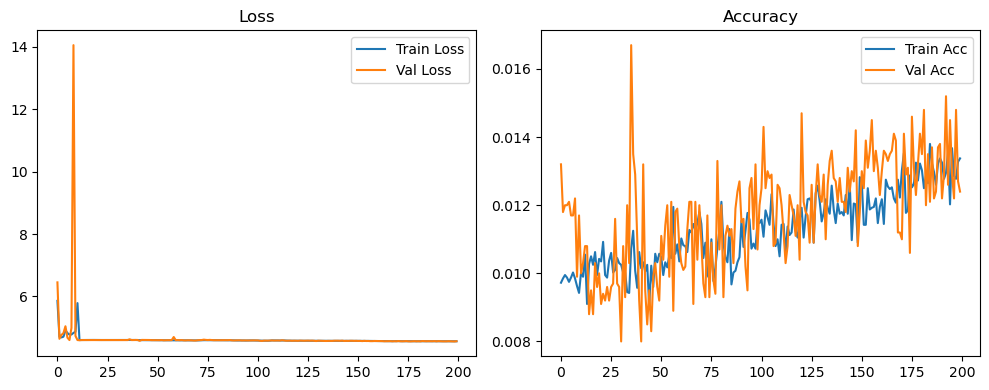

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.16it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.21it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.61it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.47it/s]

...

| LR: 0.000012 | Train Acc: 0.0097 | Val Acc: 0.0085 |: 100%|█████████▉| 199/200 [56:49<00:16, 16.71s/it]

| LR: 0.000011 | Train Acc: 0.0101 | Val Acc: 0.0088 |: 100%|█████████▉| 199/200 [57:05<00:16, 16.71s/it]

| LR: 0.000011 | Train Acc: 0.0101 | Val Acc: 0.0088 |: 100%|█████████▉| 199/200 [57:05<00:16, 16.71s/it]

| LR: 0.000011 | Train Acc: 0.0101 | Val Acc: 0.0088 |: 100%|██████████| 200/200 [57:05<00:00, 16.69s/it]

| LR: 0.000011 | Train Acc: 0.0101 | Val Acc: 0.0088 |: 100%|██████████| 200/200 [57:05<00:00, 17.13s/it]

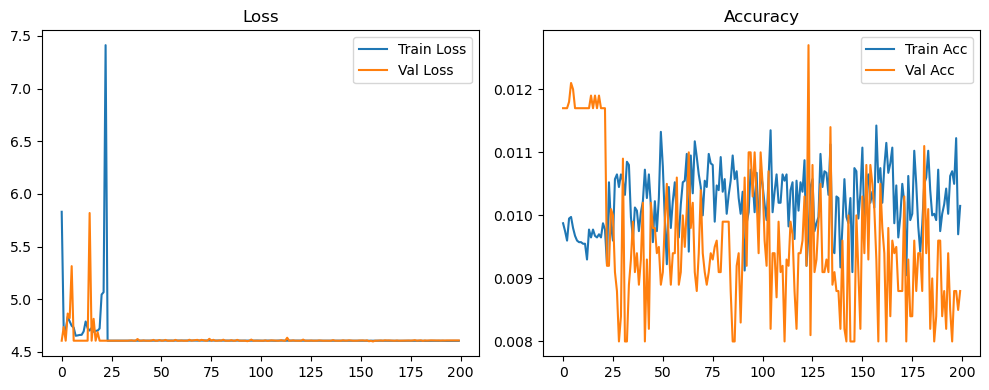

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.20it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.22it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.64it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.50it/s]

...

| LR: 0.000012 | Train Acc: 0.0103 | Val Acc: 0.0083 |: 100%|█████████▉| 199/200 [57:11<00:16, 16.83s/it]

| LR: 0.000011 | Train Acc: 0.0115 | Val Acc: 0.0092 |: 100%|█████████▉| 199/200 [57:27<00:16, 16.83s/it]

| LR: 0.000011 | Train Acc: 0.0115 | Val Acc: 0.0092 |: 100%|█████████▉| 199/200 [57:27<00:16, 16.83s/it]

| LR: 0.000011 | Train Acc: 0.0115 | Val Acc: 0.0092 |: 100%|██████████| 200/200 [57:28<00:00, 16.86s/it]

| LR: 0.000011 | Train Acc: 0.0115 | Val Acc: 0.0092 |: 100%|██████████| 200/200 [57:28<00:00, 17.24s/it]

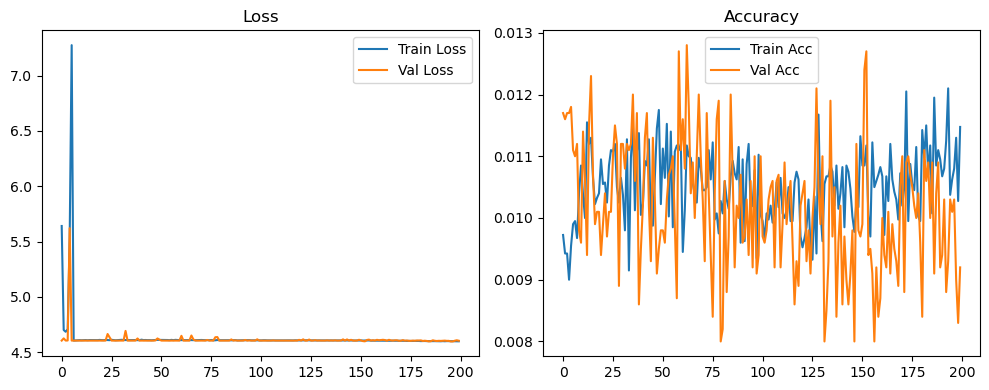

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.19it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.22it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.63it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.49it/s]

...

| LR: 0.000010 | Train Acc: 0.0115 | Val Acc: 0.0100 |: 100%|█████████▉| 199/200 [55:35<00:16, 16.26s/it]

| LR: 0.000010 | Train Acc: 0.0115 | Val Acc: 0.0096 |: 100%|█████████▉| 199/200 [55:51<00:16, 16.26s/it]

| LR: 0.000010 | Train Acc: 0.0115 | Val Acc: 0.0096 |: 100%|█████████▉| 199/200 [55:51<00:16, 16.26s/it]

| LR: 0.000010 | Train Acc: 0.0115 | Val Acc: 0.0096 |: 100%|██████████| 200/200 [55:52<00:00, 16.28s/it]

| LR: 0.000010 | Train Acc: 0.0115 | Val Acc: 0.0096 |: 100%|██████████| 200/200 [55:52<00:00, 16.76s/it]

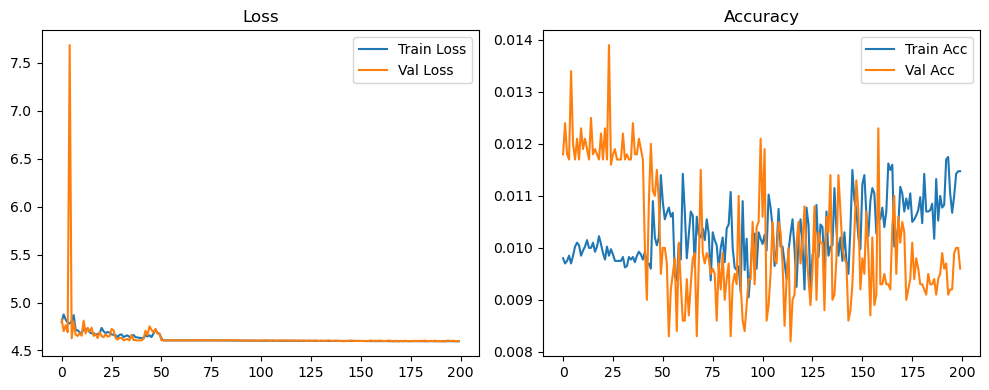

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.18it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.20it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.61it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.47it/s]

...

| LR: 0.000010 | Train Acc: 0.0110 | Val Acc: 0.0086 |: 100%|█████████▉| 199/200 [56:49<00:16, 16.78s/it]

| LR: 0.000010 | Train Acc: 0.0101 | Val Acc: 0.0086 |: 100%|█████████▉| 199/200 [57:05<00:16, 16.78s/it]

| LR: 0.000010 | Train Acc: 0.0101 | Val Acc: 0.0086 |: 100%|█████████▉| 199/200 [57:05<00:16, 16.78s/it]

| LR: 0.000010 | Train Acc: 0.0101 | Val Acc: 0.0086 |: 100%|██████████| 200/200 [57:06<00:00, 16.79s/it]

| LR: 0.000010 | Train Acc: 0.0101 | Val Acc: 0.0086 |: 100%|██████████| 200/200 [57:06<00:00, 17.13s/it]

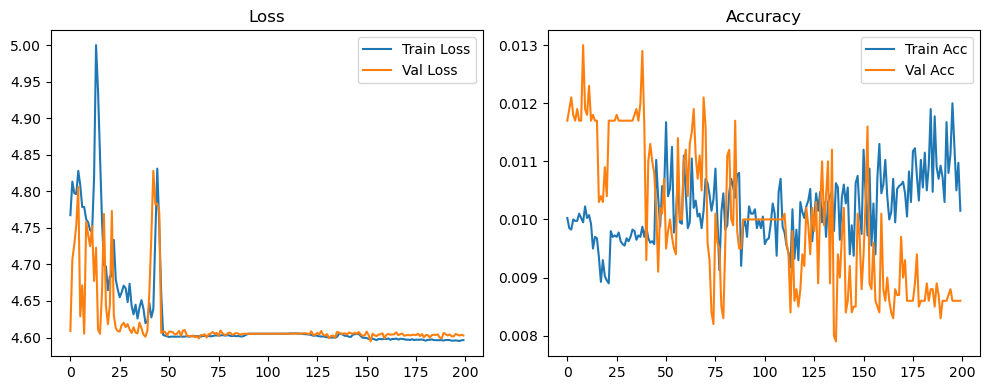

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.20it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.22it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.63it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.49it/s]

...

| LR: 0.000010 | Train Acc: 0.0100 | Val Acc: 0.0098 |: 100%|█████████▉| 199/200 [56:51<00:16, 16.75s/it]

| LR: 0.000010 | Train Acc: 0.0117 | Val Acc: 0.0094 |: 100%|█████████▉| 199/200 [57:07<00:16, 16.75s/it]

| LR: 0.000010 | Train Acc: 0.0117 | Val Acc: 0.0094 |: 100%|█████████▉| 199/200 [57:07<00:16, 16.75s/it]

| LR: 0.000010 | Train Acc: 0.0117 | Val Acc: 0.0094 |: 100%|██████████| 200/200 [57:08<00:00, 16.75s/it]

| LR: 0.000010 | Train Acc: 0.0117 | Val Acc: 0.0094 |: 100%|██████████| 200/200 [57:08<00:00, 17.14s/it]

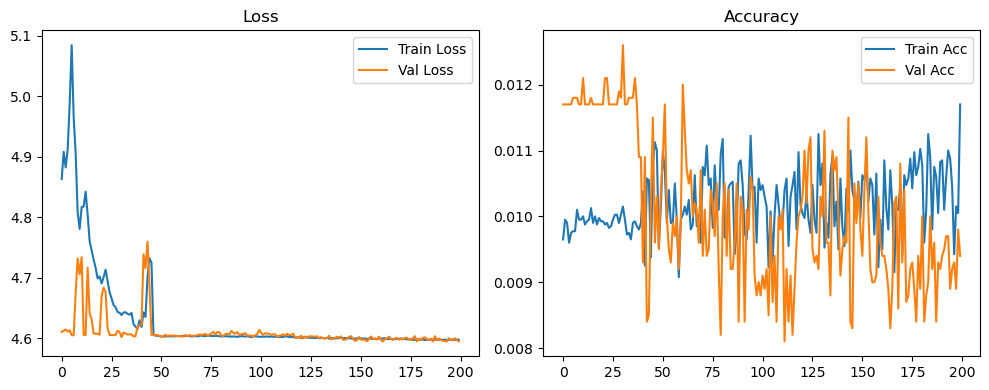

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.01it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.13it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.55it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.39it/s]

...

| LR: 0.000010 | Train Acc: 0.0101 | Val Acc: 0.0121 |: 100%|█████████▉| 199/200 [55:20<00:16, 16.27s/it]

| LR: 0.000010 | Train Acc: 0.0099 | Val Acc: 0.0120 |: 100%|█████████▉| 199/200 [55:36<00:16, 16.27s/it]

| LR: 0.000010 | Train Acc: 0.0099 | Val Acc: 0.0120 |: 100%|█████████▉| 199/200 [55:36<00:16, 16.27s/it]

| LR: 0.000010 | Train Acc: 0.0099 | Val Acc: 0.0120 |: 100%|██████████| 200/200 [55:36<00:00, 16.26s/it]

| LR: 0.000010 | Train Acc: 0.0099 | Val Acc: 0.0120 |: 100%|██████████| 200/200 [55:36<00:00, 16.68s/it]

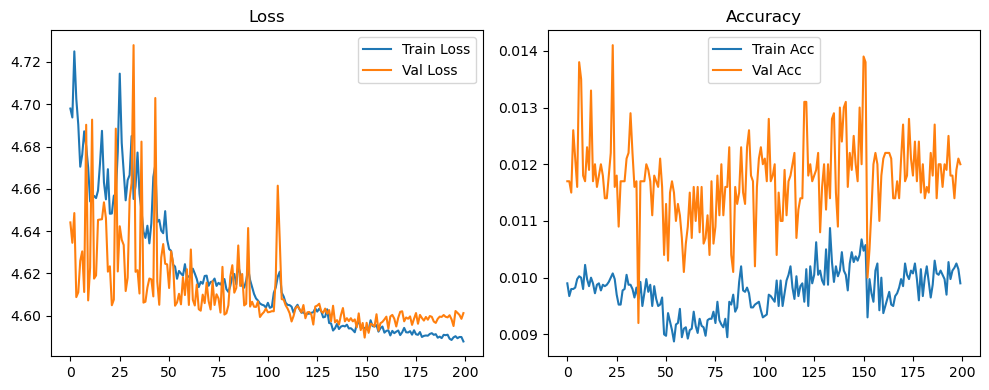

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.18it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.22it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.62it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.48it/s]

...

| LR: 0.000010 | Train Acc: 0.0109 | Val Acc: 0.0100 |: 100%|█████████▉| 199/200 [56:56<00:16, 16.83s/it]

| LR: 0.000010 | Train Acc: 0.0101 | Val Acc: 0.0091 |: 100%|█████████▉| 199/200 [57:12<00:16, 16.83s/it]

| LR: 0.000010 | Train Acc: 0.0101 | Val Acc: 0.0091 |: 100%|█████████▉| 199/200 [57:12<00:16, 16.83s/it]

| LR: 0.000010 | Train Acc: 0.0101 | Val Acc: 0.0091 |: 100%|██████████| 200/200 [57:12<00:00, 16.82s/it]

| LR: 0.000010 | Train Acc: 0.0101 | Val Acc: 0.0091 |: 100%|██████████| 200/200 [57:12<00:00, 17.16s/it]

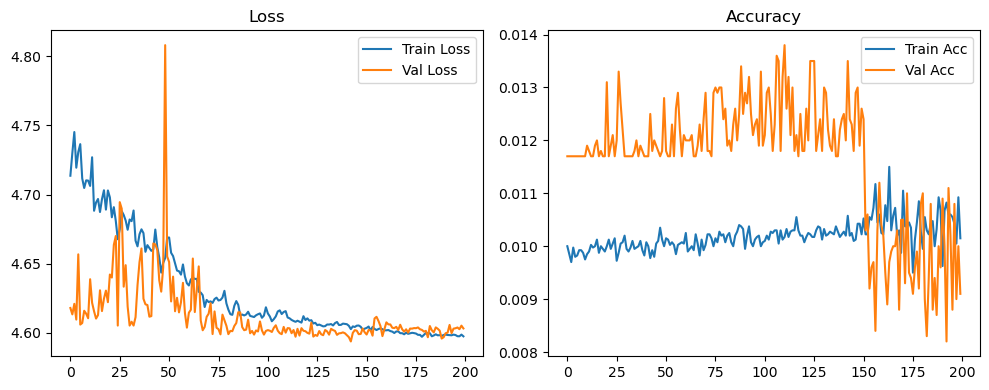

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.21it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.22it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.62it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.49it/s]

...

| LR: 0.000010 | Train Acc: 0.0094 | Val Acc: 0.0086 |: 100%|█████████▉| 199/200 [56:50<00:16, 16.81s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0095 |: 100%|█████████▉| 199/200 [57:06<00:16, 16.81s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0095 |: 100%|█████████▉| 199/200 [57:06<00:16, 16.81s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0095 |: 100%|██████████| 200/200 [57:07<00:00, 16.78s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0095 |: 100%|██████████| 200/200 [57:07<00:00, 17.14s/it]

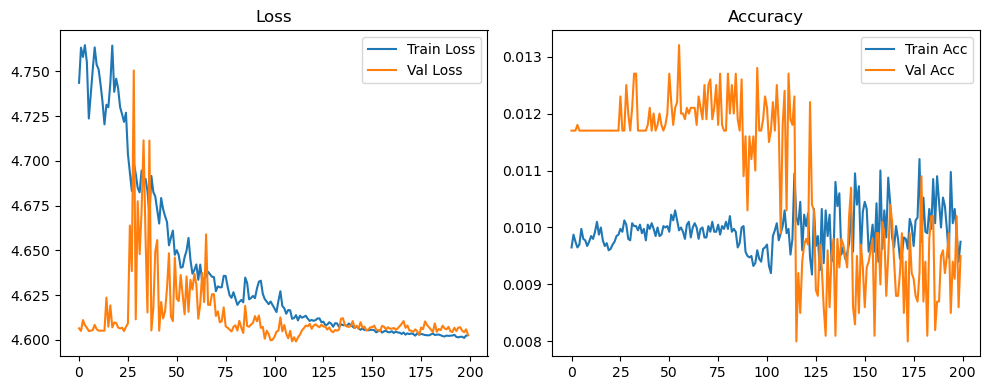

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.18it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.20it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.61it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.47it/s]

...

| LR: 0.000010 | Train Acc: 0.0106 | Val Acc: 0.0125 |: 100%|█████████▉| 199/200 [55:32<00:16, 16.55s/it]

| LR: 0.000010 | Train Acc: 0.0107 | Val Acc: 0.0125 |: 100%|█████████▉| 199/200 [55:49<00:16, 16.55s/it]

| LR: 0.000010 | Train Acc: 0.0107 | Val Acc: 0.0125 |: 100%|█████████▉| 199/200 [55:49<00:16, 16.55s/it]

| LR: 0.000010 | Train Acc: 0.0107 | Val Acc: 0.0125 |: 100%|██████████| 200/200 [55:49<00:00, 16.54s/it]

| LR: 0.000010 | Train Acc: 0.0107 | Val Acc: 0.0125 |: 100%|██████████| 200/200 [55:49<00:00, 16.75s/it]

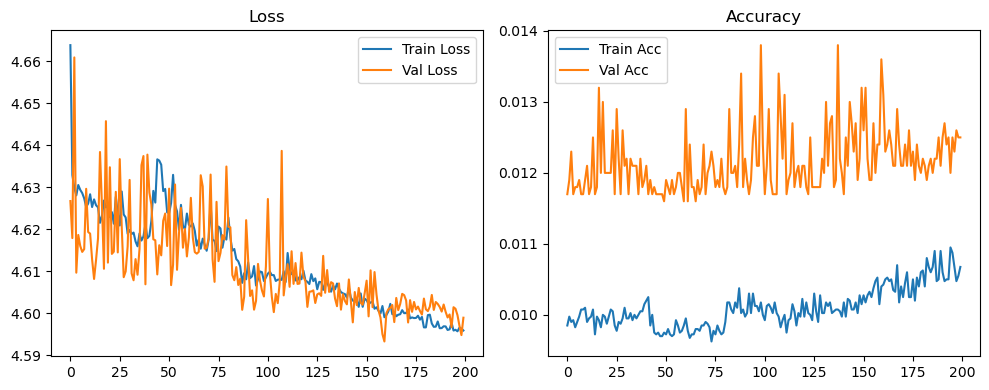

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.20it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.21it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.61it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.48it/s]

...

| LR: 0.000010 | Train Acc: 0.0098 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [56:49<00:16, 16.90s/it]

| LR: 0.000010 | Train Acc: 0.0098 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [57:06<00:16, 16.90s/it]

| LR: 0.000010 | Train Acc: 0.0098 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [57:06<00:16, 16.90s/it]

| LR: 0.000010 | Train Acc: 0.0098 | Val Acc: 0.0117 |: 100%|██████████| 200/200 [57:06<00:00, 16.87s/it]

| LR: 0.000010 | Train Acc: 0.0098 | Val Acc: 0.0117 |: 100%|██████████| 200/200 [57:06<00:00, 17.13s/it]

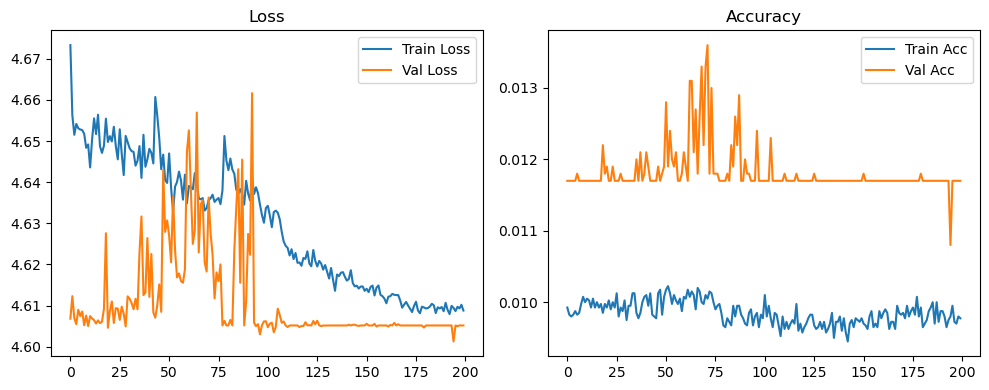

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.18it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.21it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.62it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.48it/s]

...

| LR: 0.000010 | Train Acc: 0.0100 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [56:46<00:16, 16.78s/it]

| LR: 0.000010 | Train Acc: 0.0101 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [57:03<00:16, 16.78s/it]

| LR: 0.000010 | Train Acc: 0.0101 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [57:03<00:16, 16.78s/it]

| LR: 0.000010 | Train Acc: 0.0101 | Val Acc: 0.0117 |: 100%|██████████| 200/200 [57:03<00:00, 16.76s/it]

| LR: 0.000010 | Train Acc: 0.0101 | Val Acc: 0.0117 |: 100%|██████████| 200/200 [57:03<00:00, 17.12s/it]

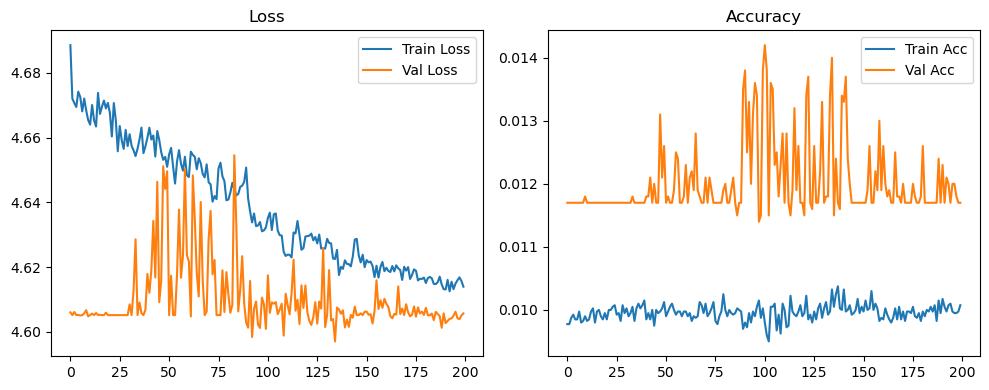

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.20it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.22it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.63it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.49it/s]

...

| LR: 0.000012 | Train Acc: 0.0100 | Val Acc: 0.0118 |: 100%|█████████▉| 199/200 [41:23<00:11, 11.73s/it]

| LR: 0.000011 | Train Acc: 0.0100 | Val Acc: 0.0119 |: 100%|█████████▉| 199/200 [41:34<00:11, 11.73s/it]

| LR: 0.000011 | Train Acc: 0.0100 | Val Acc: 0.0119 |: 100%|█████████▉| 199/200 [41:34<00:11, 11.73s/it]

| LR: 0.000011 | Train Acc: 0.0100 | Val Acc: 0.0119 |: 100%|██████████| 200/200 [41:34<00:00, 11.71s/it]

| LR: 0.000011 | Train Acc: 0.0100 | Val Acc: 0.0119 |: 100%|██████████| 200/200 [41:34<00:00, 12.47s/it]

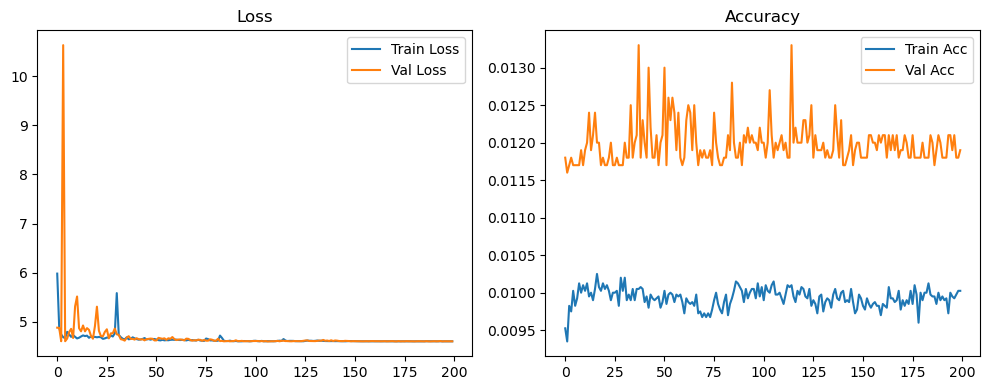

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.22it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.24it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.64it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.51it/s]

...

| LR: 0.000012 | Train Acc: 0.0112 | Val Acc: 0.0080 |: 100%|█████████▉| 199/200 [42:29<00:12, 12.07s/it]

| LR: 0.000011 | Train Acc: 0.0104 | Val Acc: 0.0097 |: 100%|█████████▉| 199/200 [42:40<00:12, 12.07s/it]

| LR: 0.000011 | Train Acc: 0.0104 | Val Acc: 0.0097 |: 100%|█████████▉| 199/200 [42:40<00:12, 12.07s/it]

| LR: 0.000011 | Train Acc: 0.0104 | Val Acc: 0.0097 |: 100%|██████████| 200/200 [42:41<00:00, 12.04s/it]

| LR: 0.000011 | Train Acc: 0.0104 | Val Acc: 0.0097 |: 100%|██████████| 200/200 [42:41<00:00, 12.81s/it]

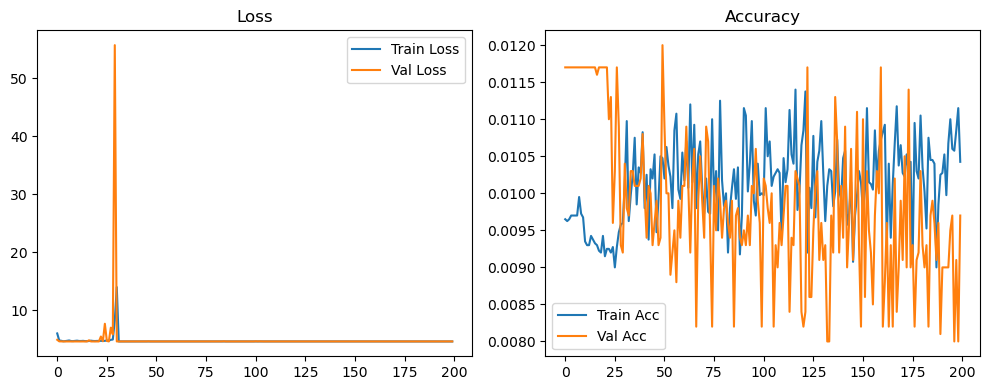

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.19it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.19it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.59it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.46it/s]

...

| LR: 0.000012 | Train Acc: 0.0109 | Val Acc: 0.0091 |: 100%|█████████▉| 199/200 [42:35<00:12, 12.13s/it]

| LR: 0.000011 | Train Acc: 0.0099 | Val Acc: 0.0080 |: 100%|█████████▉| 199/200 [42:47<00:12, 12.13s/it]

| LR: 0.000011 | Train Acc: 0.0099 | Val Acc: 0.0080 |: 100%|█████████▉| 199/200 [42:47<00:12, 12.13s/it]

| LR: 0.000011 | Train Acc: 0.0099 | Val Acc: 0.0080 |: 100%|██████████| 200/200 [42:47<00:00, 12.10s/it]

| LR: 0.000011 | Train Acc: 0.0099 | Val Acc: 0.0080 |: 100%|██████████| 200/200 [42:47<00:00, 12.84s/it]

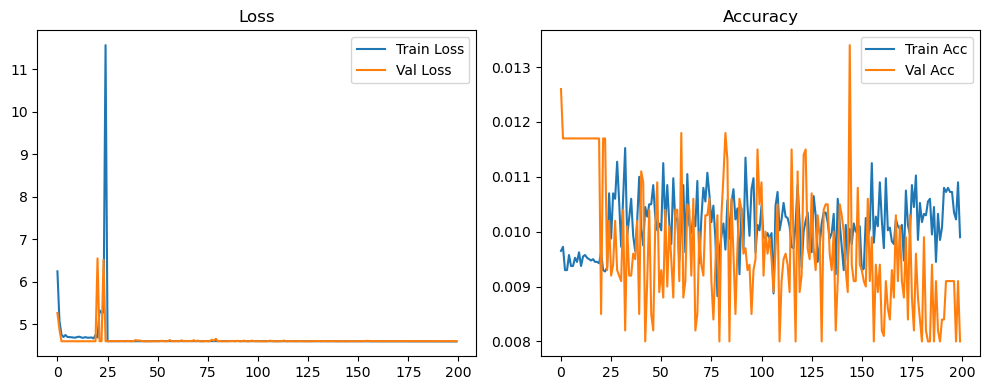

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.18it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.22it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.64it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.49it/s]

...

| LR: 0.000010 | Train Acc: 0.0101 | Val Acc: 0.0121 |: 100%|█████████▉| 199/200 [41:19<00:11, 11.72s/it]

| LR: 0.000010 | Train Acc: 0.0102 | Val Acc: 0.0124 |: 100%|█████████▉| 199/200 [41:30<00:11, 11.72s/it]

| LR: 0.000010 | Train Acc: 0.0102 | Val Acc: 0.0124 |: 100%|█████████▉| 199/200 [41:30<00:11, 11.72s/it]

| LR: 0.000010 | Train Acc: 0.0102 | Val Acc: 0.0124 |: 100%|██████████| 200/200 [41:31<00:00, 11.78s/it]

| LR: 0.000010 | Train Acc: 0.0102 | Val Acc: 0.0124 |: 100%|██████████| 200/200 [41:31<00:00, 12.46s/it]

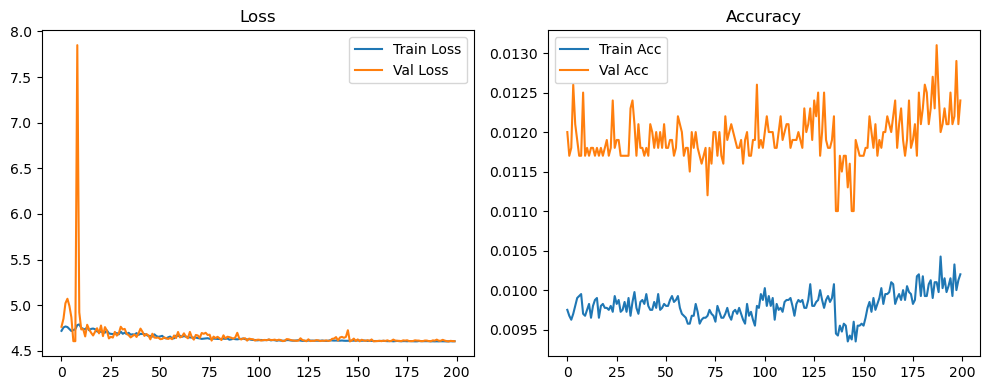

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.02it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.13it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.54it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.38it/s]

...

| LR: 0.000010 | Train Acc: 0.0098 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [42:31<00:12, 12.12s/it]

| LR: 0.000010 | Train Acc: 0.0099 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [42:43<00:12, 12.12s/it]

| LR: 0.000010 | Train Acc: 0.0099 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [42:43<00:12, 12.12s/it]

| LR: 0.000010 | Train Acc: 0.0099 | Val Acc: 0.0117 |: 100%|██████████| 200/200 [42:43<00:00, 12.11s/it]

| LR: 0.000010 | Train Acc: 0.0099 | Val Acc: 0.0117 |: 100%|██████████| 200/200 [42:43<00:00, 12.82s/it]

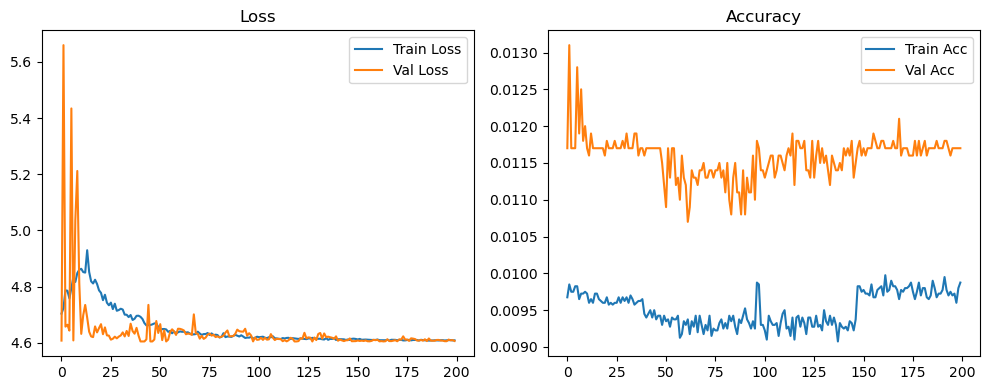

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.01it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.13it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.55it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.39it/s]

...

| LR: 0.000010 | Train Acc: 0.0100 | Val Acc: 0.0121 |: 100%|█████████▉| 199/200 [42:30<00:12, 12.12s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [42:42<00:12, 12.12s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [42:42<00:12, 12.12s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0117 |: 100%|██████████| 200/200 [42:43<00:00, 12.12s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0117 |: 100%|██████████| 200/200 [42:43<00:00, 12.82s/it]

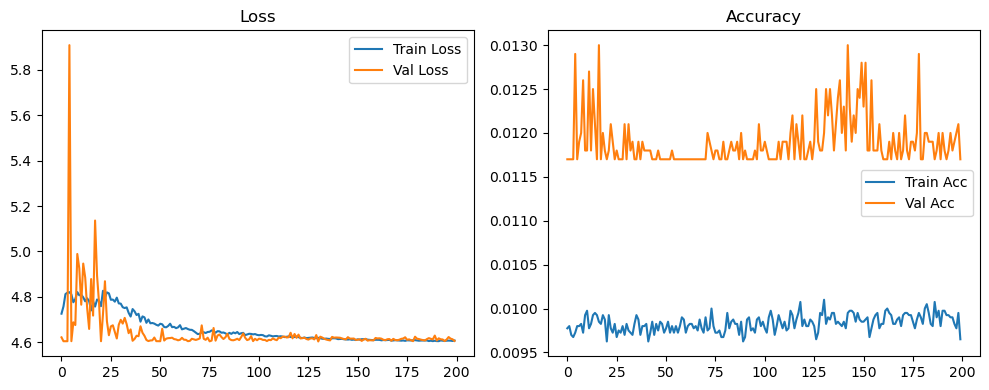

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.18it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.10it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.51it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.38it/s]

...

| LR: 0.000010 | Train Acc: 0.0095 | Val Acc: 0.0126 |: 100%|█████████▉| 199/200 [41:19<00:11, 11.73s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0119 |: 100%|█████████▉| 199/200 [41:31<00:11, 11.73s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0119 |: 100%|█████████▉| 199/200 [41:31<00:11, 11.73s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0119 |: 100%|██████████| 200/200 [41:31<00:00, 11.69s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0119 |: 100%|██████████| 200/200 [41:31<00:00, 12.46s/it]

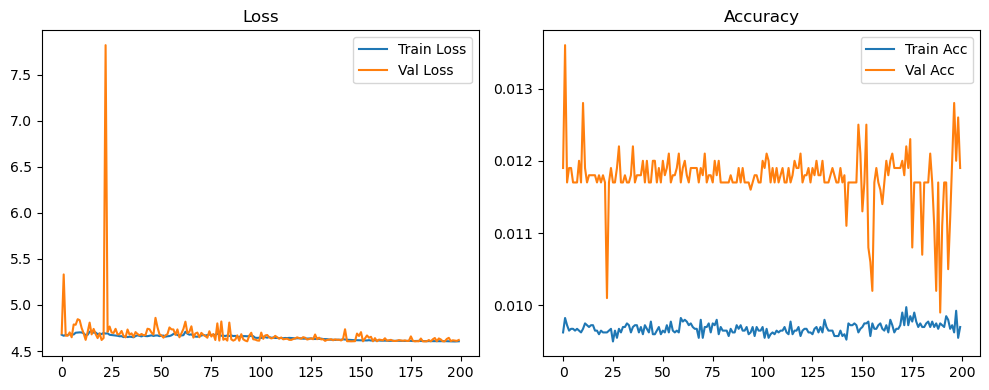

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.18it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.21it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.61it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.47it/s]

...

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0118 |: 100%|█████████▉| 199/200 [42:29<00:12, 12.08s/it]

| LR: 0.000010 | Train Acc: 0.0098 | Val Acc: 0.0120 |: 100%|█████████▉| 199/200 [42:41<00:12, 12.08s/it]

| LR: 0.000010 | Train Acc: 0.0098 | Val Acc: 0.0120 |: 100%|█████████▉| 199/200 [42:41<00:12, 12.08s/it]

| LR: 0.000010 | Train Acc: 0.0098 | Val Acc: 0.0120 |: 100%|██████████| 200/200 [42:41<00:00, 12.11s/it]

| LR: 0.000010 | Train Acc: 0.0098 | Val Acc: 0.0120 |: 100%|██████████| 200/200 [42:41<00:00, 12.81s/it]

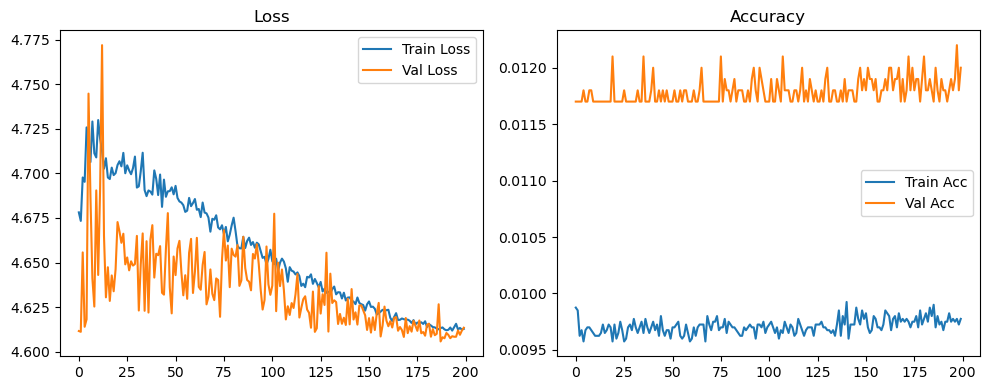

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.18it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.22it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.63it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.49it/s]

...

| LR: 0.000010 | Train Acc: 0.0096 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [42:32<00:12, 12.08s/it]

| LR: 0.000010 | Train Acc: 0.0095 | Val Acc: 0.0110 |: 100%|█████████▉| 199/200 [42:44<00:12, 12.08s/it]

| LR: 0.000010 | Train Acc: 0.0095 | Val Acc: 0.0110 |: 100%|█████████▉| 199/200 [42:44<00:12, 12.08s/it]

| LR: 0.000010 | Train Acc: 0.0095 | Val Acc: 0.0110 |: 100%|██████████| 200/200 [42:44<00:00, 12.09s/it]

| LR: 0.000010 | Train Acc: 0.0095 | Val Acc: 0.0110 |: 100%|██████████| 200/200 [42:44<00:00, 12.82s/it]

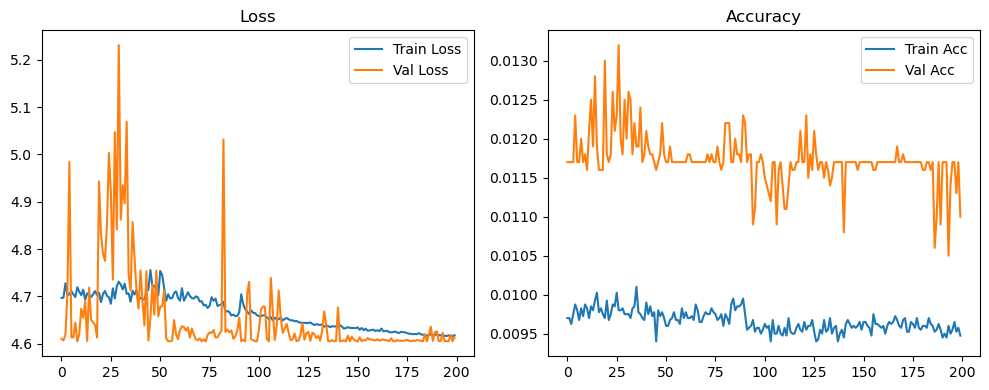

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.20it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.22it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.63it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.49it/s]

...

| LR: 0.000010 | Train Acc: 0.0098 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [41:19<00:11, 11.71s/it]

| LR: 0.000010 | Train Acc: 0.0100 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [41:31<00:11, 11.71s/it]

| LR: 0.000010 | Train Acc: 0.0100 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [41:31<00:11, 11.71s/it]

| LR: 0.000010 | Train Acc: 0.0100 | Val Acc: 0.0117 |: 100%|██████████| 200/200 [41:31<00:00, 11.70s/it]

| LR: 0.000010 | Train Acc: 0.0100 | Val Acc: 0.0117 |: 100%|██████████| 200/200 [41:31<00:00, 12.46s/it]

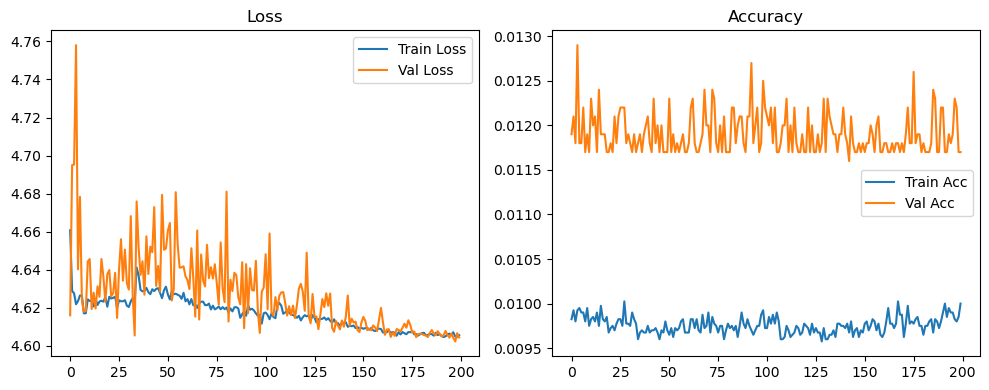

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.23it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.23it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.65it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.51it/s]

...

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0118 |: 100%|█████████▉| 199/200 [42:28<00:12, 12.01s/it]

| LR: 0.000010 | Train Acc: 0.0096 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [42:40<00:12, 12.01s/it]

| LR: 0.000010 | Train Acc: 0.0096 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [42:40<00:12, 12.01s/it]

| LR: 0.000010 | Train Acc: 0.0096 | Val Acc: 0.0117 |: 100%|██████████| 200/200 [42:40<00:00, 12.00s/it]

| LR: 0.000010 | Train Acc: 0.0096 | Val Acc: 0.0117 |: 100%|██████████| 200/200 [42:40<00:00, 12.80s/it]

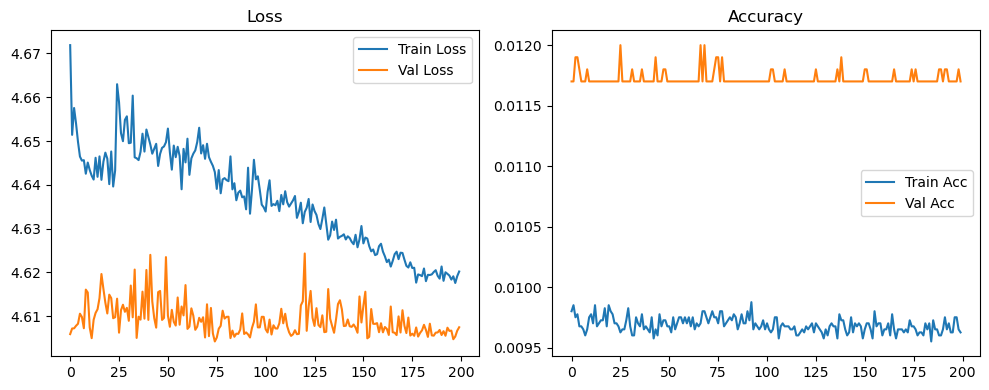

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.21it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.23it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.64it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.50it/s]

...

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [42:30<00:12, 12.02s/it]

| LR: 0.000010 | Train Acc: 0.0096 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [42:42<00:12, 12.02s/it]

| LR: 0.000010 | Train Acc: 0.0096 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [42:42<00:12, 12.02s/it]

| LR: 0.000010 | Train Acc: 0.0096 | Val Acc: 0.0117 |: 100%|██████████| 200/200 [42:42<00:00, 12.02s/it]

| LR: 0.000010 | Train Acc: 0.0096 | Val Acc: 0.0117 |: 100%|██████████| 200/200 [42:42<00:00, 12.81s/it]

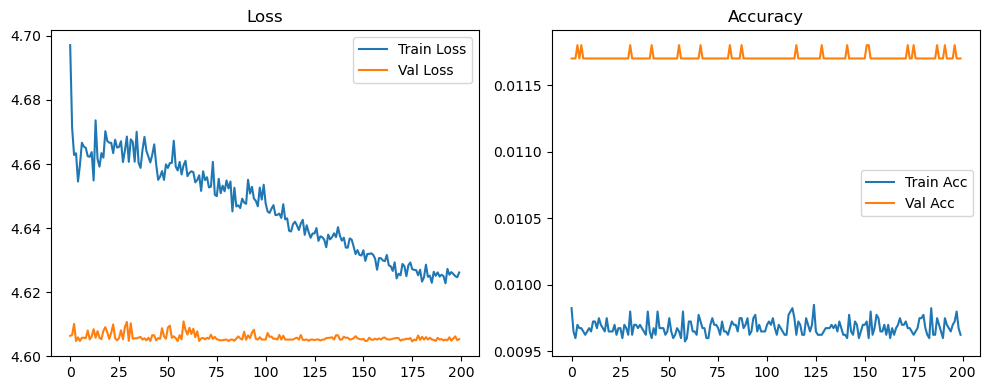

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.19it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.21it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.62it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.48it/s]

...

| LR: 0.000012 | Train Acc: 0.0096 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [37:24<00:09,  9.76s/it]

| LR: 0.000011 | Train Acc: 0.0097 | Val Acc: 0.0118 |: 100%|█████████▉| 199/200 [37:33<00:09,  9.76s/it]

| LR: 0.000011 | Train Acc: 0.0097 | Val Acc: 0.0118 |: 100%|█████████▉| 199/200 [37:33<00:09,  9.76s/it]

| LR: 0.000011 | Train Acc: 0.0097 | Val Acc: 0.0118 |: 100%|██████████| 200/200 [37:33<00:00,  9.76s/it]

| LR: 0.000011 | Train Acc: 0.0097 | Val Acc: 0.0118 |: 100%|██████████| 200/200 [37:33<00:00, 11.27s/it]

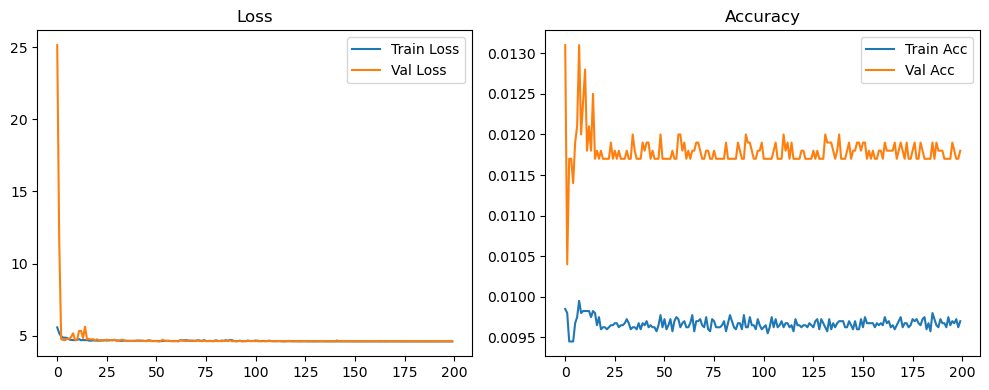

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.20it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.23it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.65it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.51it/s]

...

| LR: 0.000012 | Train Acc: 0.0107 | Val Acc: 0.0083 |: 100%|█████████▉| 199/200 [38:32<00:10, 10.05s/it]

| LR: 0.000011 | Train Acc: 0.0114 | Val Acc: 0.0080 |: 100%|█████████▉| 199/200 [38:42<00:10, 10.05s/it]

| LR: 0.000011 | Train Acc: 0.0114 | Val Acc: 0.0080 |: 100%|█████████▉| 199/200 [38:42<00:10, 10.05s/it]

| LR: 0.000011 | Train Acc: 0.0114 | Val Acc: 0.0080 |: 100%|██████████| 200/200 [38:42<00:00, 10.07s/it]

| LR: 0.000011 | Train Acc: 0.0114 | Val Acc: 0.0080 |: 100%|██████████| 200/200 [38:42<00:00, 11.61s/it]

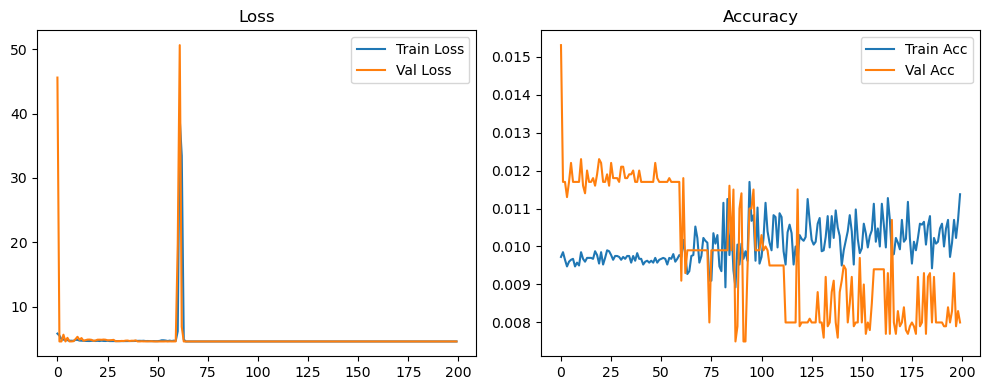

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.19it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.21it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.62it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.48it/s]

...

| LR: 0.000012 | Train Acc: 0.0095 | Val Acc: 0.0110 |: 100%|█████████▉| 199/200 [38:29<00:10, 10.07s/it]

| LR: 0.000011 | Train Acc: 0.0100 | Val Acc: 0.0084 |: 100%|█████████▉| 199/200 [38:39<00:10, 10.07s/it]

| LR: 0.000011 | Train Acc: 0.0100 | Val Acc: 0.0084 |: 100%|█████████▉| 199/200 [38:39<00:10, 10.07s/it]

| LR: 0.000011 | Train Acc: 0.0100 | Val Acc: 0.0084 |: 100%|██████████| 200/200 [38:39<00:00, 10.07s/it]

| LR: 0.000011 | Train Acc: 0.0100 | Val Acc: 0.0084 |: 100%|██████████| 200/200 [38:39<00:00, 11.60s/it]

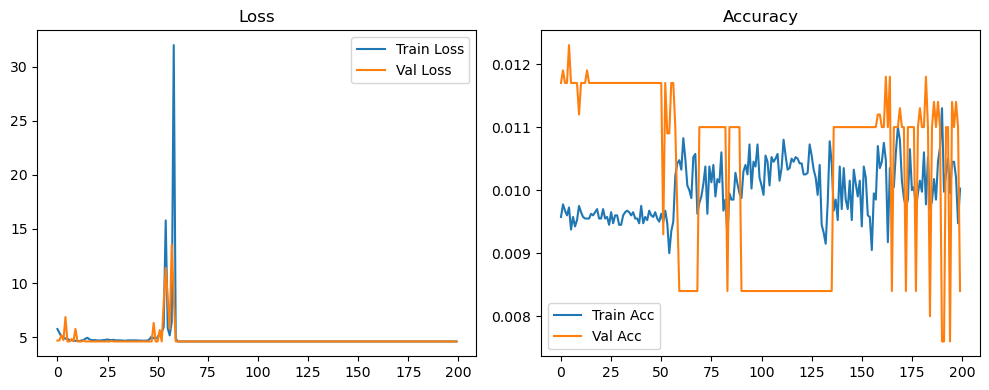

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:01<00:02,  1.00s/it]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.11it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.52it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.36it/s]

...

| LR: 0.000010 | Train Acc: 0.0093 | Val Acc: 0.0114 |: 100%|█████████▉| 199/200 [37:18<00:09,  9.73s/it]

| LR: 0.000010 | Train Acc: 0.0096 | Val Acc: 0.0112 |: 100%|█████████▉| 199/200 [37:28<00:09,  9.73s/it]

| LR: 0.000010 | Train Acc: 0.0096 | Val Acc: 0.0112 |: 100%|█████████▉| 199/200 [37:28<00:09,  9.73s/it]

| LR: 0.000010 | Train Acc: 0.0096 | Val Acc: 0.0112 |: 100%|██████████| 200/200 [37:28<00:00,  9.73s/it]

| LR: 0.000010 | Train Acc: 0.0096 | Val Acc: 0.0112 |: 100%|██████████| 200/200 [37:28<00:00, 11.24s/it]

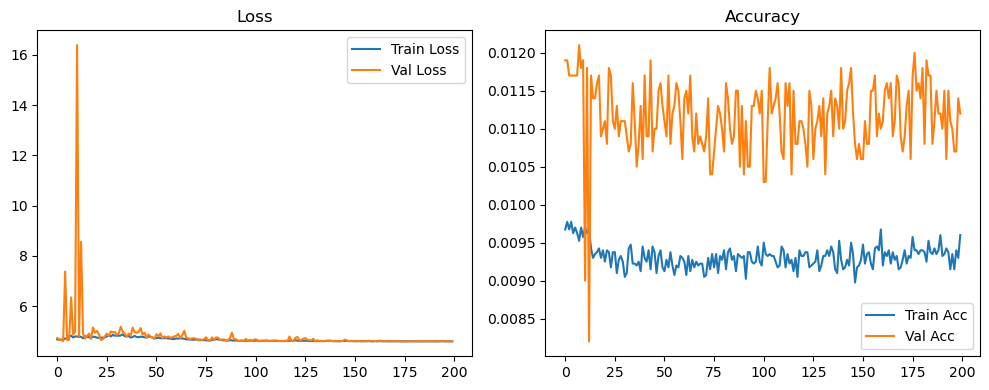

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.19it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.22it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.62it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.48it/s]

...

| LR: 0.000010 | Train Acc: 0.0094 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [38:26<00:10, 10.08s/it]

| LR: 0.000010 | Train Acc: 0.0095 | Val Acc: 0.0111 |: 100%|█████████▉| 199/200 [38:36<00:10, 10.08s/it]

| LR: 0.000010 | Train Acc: 0.0095 | Val Acc: 0.0111 |: 100%|█████████▉| 199/200 [38:36<00:10, 10.08s/it]

| LR: 0.000010 | Train Acc: 0.0095 | Val Acc: 0.0111 |: 100%|██████████| 200/200 [38:36<00:00, 10.07s/it]

| LR: 0.000010 | Train Acc: 0.0095 | Val Acc: 0.0111 |: 100%|██████████| 200/200 [38:36<00:00, 11.58s/it]

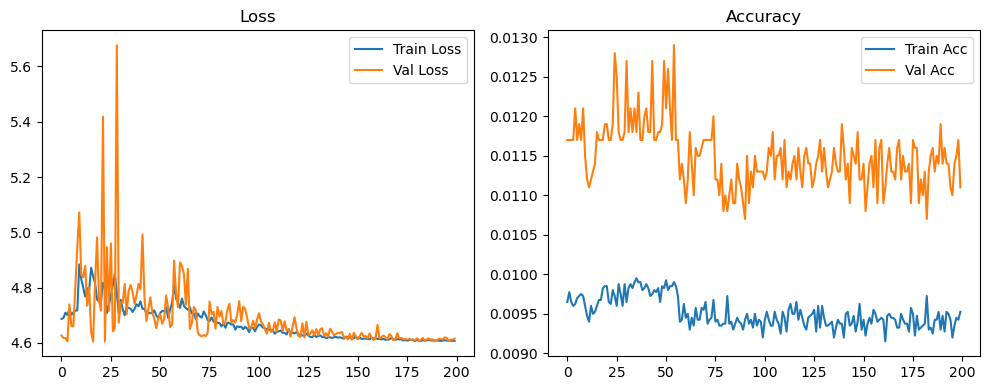

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.20it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.23it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.64it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.50it/s]

...

| LR: 0.000010 | Train Acc: 0.0096 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [38:25<00:10, 10.08s/it]

| LR: 0.000010 | Train Acc: 0.0096 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [38:35<00:10, 10.08s/it]

| LR: 0.000010 | Train Acc: 0.0096 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [38:35<00:10, 10.08s/it]

| LR: 0.000010 | Train Acc: 0.0096 | Val Acc: 0.0117 |: 100%|██████████| 200/200 [38:35<00:00, 10.05s/it]

| LR: 0.000010 | Train Acc: 0.0096 | Val Acc: 0.0117 |: 100%|██████████| 200/200 [38:35<00:00, 11.58s/it]

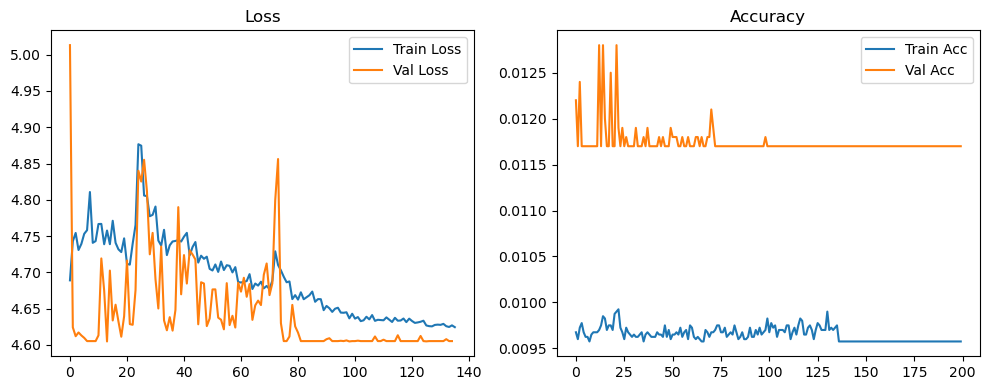

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.19it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.21it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.62it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.48it/s]

...

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0119 |: 100%|█████████▉| 199/200 [37:15<00:09,  9.71s/it]

| LR: 0.000010 | Train Acc: 0.0098 | Val Acc: 0.0118 |: 100%|█████████▉| 199/200 [37:25<00:09,  9.71s/it]

| LR: 0.000010 | Train Acc: 0.0098 | Val Acc: 0.0118 |: 100%|█████████▉| 199/200 [37:25<00:09,  9.71s/it]

| LR: 0.000010 | Train Acc: 0.0098 | Val Acc: 0.0118 |: 100%|██████████| 200/200 [37:25<00:00,  9.73s/it]

| LR: 0.000010 | Train Acc: 0.0098 | Val Acc: 0.0118 |: 100%|██████████| 200/200 [37:25<00:00, 11.23s/it]

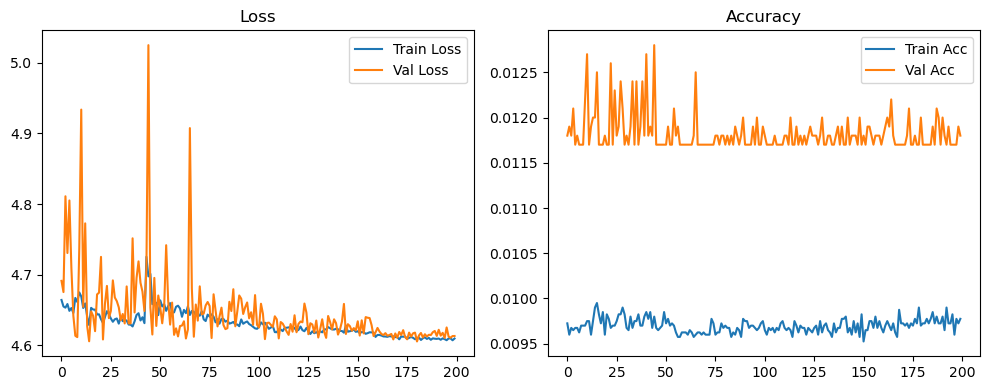

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.19it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.22it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.62it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.48it/s]

...

| LR: 0.000010 | Train Acc: 0.0096 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [38:28<00:10, 10.11s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [38:37<00:10, 10.11s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [38:37<00:10, 10.11s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0117 |: 100%|██████████| 200/200 [38:38<00:00, 10.10s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0117 |: 100%|██████████| 200/200 [38:38<00:00, 11.59s/it]

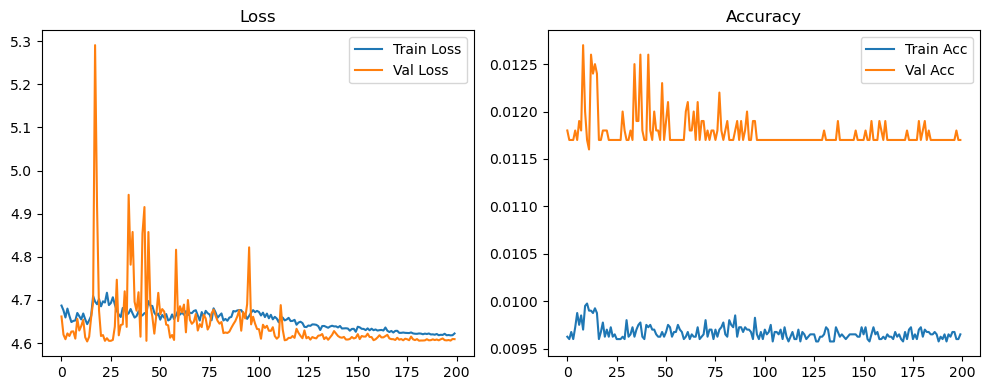

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.20it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.23it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.64it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.50it/s]

...

| LR: 0.000010 | Train Acc: 0.0098 | Val Acc: 0.0118 |: 100%|█████████▉| 199/200 [38:34<00:10, 10.12s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [38:44<00:10, 10.12s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [38:44<00:10, 10.12s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0117 |: 100%|██████████| 200/200 [38:44<00:00, 10.13s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0117 |: 100%|██████████| 200/200 [38:44<00:00, 11.62s/it]

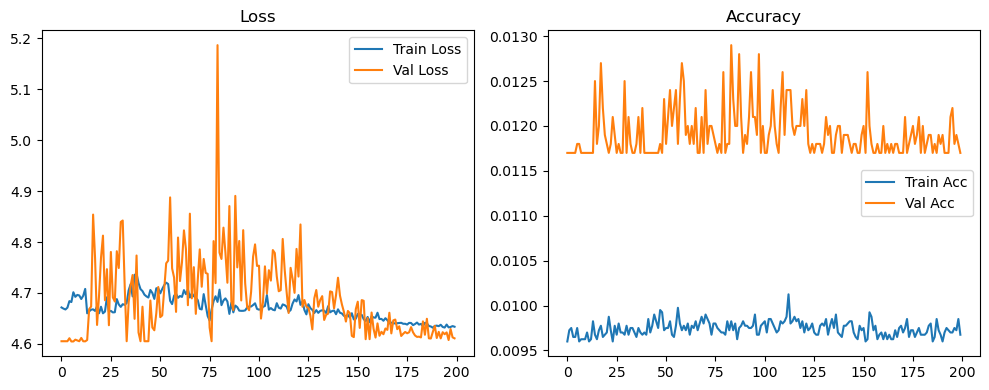

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.18it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.21it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.62it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.48it/s]

...

| LR: 0.000010 | Train Acc: 0.0100 | Val Acc: 0.0119 |: 100%|█████████▉| 199/200 [37:12<00:09,  9.73s/it]

| LR: 0.000010 | Train Acc: 0.0099 | Val Acc: 0.0118 |: 100%|█████████▉| 199/200 [37:21<00:09,  9.73s/it]

| LR: 0.000010 | Train Acc: 0.0099 | Val Acc: 0.0118 |: 100%|█████████▉| 199/200 [37:21<00:09,  9.73s/it]

| LR: 0.000010 | Train Acc: 0.0099 | Val Acc: 0.0118 |: 100%|██████████| 200/200 [37:22<00:00,  9.72s/it]

| LR: 0.000010 | Train Acc: 0.0099 | Val Acc: 0.0118 |: 100%|██████████| 200/200 [37:22<00:00, 11.21s/it]

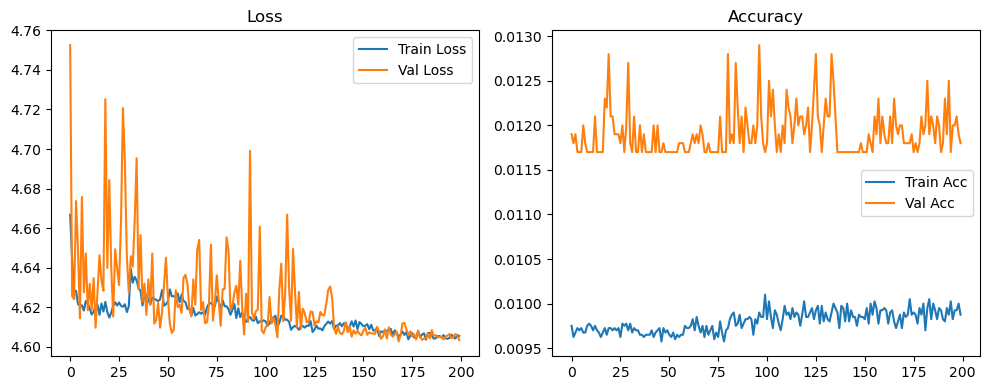

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.19it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.21it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.62it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.48it/s]

...

| LR: 0.000010 | Train Acc: 0.0099 | Val Acc: 0.0117 |: 100%|█████████▉| 199/200 [38:24<00:10, 10.07s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0118 |: 100%|█████████▉| 199/200 [38:34<00:10, 10.07s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0118 |: 100%|█████████▉| 199/200 [38:34<00:10, 10.07s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0118 |: 100%|██████████| 200/200 [38:34<00:00, 10.11s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0118 |: 100%|██████████| 200/200 [38:34<00:00, 11.57s/it]

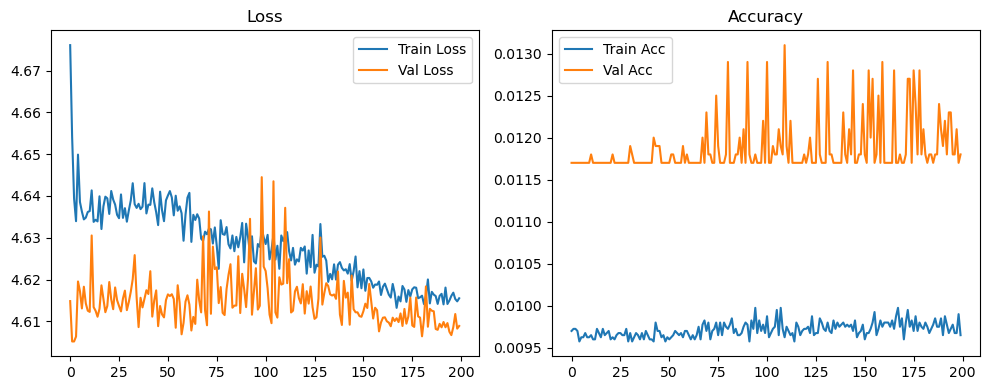

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.19it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.21it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.62it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.48it/s]

...

| LR: 0.000010 | Train Acc: 0.0099 | Val Acc: 0.0121 |: 100%|█████████▉| 199/200 [38:26<00:10, 10.08s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0119 |: 100%|█████████▉| 199/200 [38:36<00:10, 10.08s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0119 |: 100%|█████████▉| 199/200 [38:36<00:10, 10.08s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0119 |: 100%|██████████| 200/200 [38:37<00:00, 10.07s/it]

| LR: 0.000010 | Train Acc: 0.0097 | Val Acc: 0.0119 |: 100%|██████████| 200/200 [38:37<00:00, 11.59s/it]

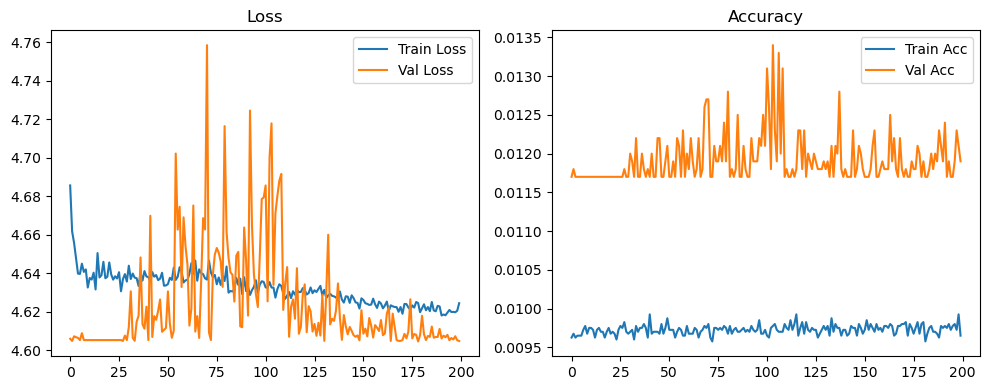

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.18it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.21it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.62it/s]

Evaluation: 100%|██████████| 3/3 [00:02<00:00,  1.48it/s]

Original Model Final Test Loss: 4.6093 Accuracy: 0.0102




🏆 Best Config: batch128_lr_max_0.01_min_1e-05_dp0.0 Accuracy: 0.0142


In [19]:
Hyperparameter_searching(epochs, batch_sizes, lr_max_pool, lr_min_pool, dropout_rates)